# Explore Prompts Dataset

Pull prompts from PromptLab and explore their distribution across tasks, datasets, and prompters.

## Data Loading & Exploration

In [1]:
import requests
import pandas as pd

# Fetch prompts from PromptLab
api_response = requests.get(
    url='https://promptlab.up.railway.app/api/prompt/list?project_secret_key=6Wirj'
)
assert api_response.ok, 'Failed to fetch prompts'
prompts = api_response.json()
print(f'Total prompts fetched: {len(prompts)}')

Total prompts fetched: 365


In [2]:
# Convert to DataFrame for easier exploration
df = pd.DataFrame(prompts)

# Extract task name from the nested dict
df['task_name'] = df['task'].apply(lambda t: t['name'] if isinstance(t, dict) else t)

print(f'Columns: {list(df.columns)}')
print(f'\nShape: {df.shape}')
df.head(3)

Columns: ['id', 'tags', 'name', 'task', 'status', 'template', 'created_by', 'dataset_name', 'dataset_subset', 'answer_choices', 'text_direction', 'task_name']

Shape: (365, 12)


,id,tags,name,task,status,template,created_by,dataset_name,dataset_subset,answer_choices,text_direction,task_name
0,14901,[],A Simple Test Prompt,{'name': 'dialect identification'},DRAFT,Please predict the most suitable dialect for t...,irfan,arbml/AraBench_dev,default,"[Tunisian, MSA, Morrocan, Qatari, Egyptian, Le...",ltr,dialect identification
1,14898,"[, Zero-shot COT]",Prompt with zero-shot chain of thoughts,{'name': 'claim verification'},APPROVED,For the following task you have to label if th...,ahmed,arbml/ANS_stance,default,"[disagree, agree, other]",ltr,claim verification
2,14897,[Meta prompting],Structured instruction for the model,{'name': 'stance detection'},APPROVED,For the given task you have to follow this str...,ahmed,arbml/ANS_stance,default,"[disagree, agree, other]",ltr,stance detection


In [3]:
# Look at unique values for key fields
print('=== Status values ===')
print(df['status'].value_counts())
print(f'\n=== Unique tasks ({df["task_name"].nunique()}) ===')
print(df['task_name'].value_counts())
print(f'\n=== Unique prompters ({df["created_by"].nunique()}) ===')
print(df['created_by'].value_counts())
print(f'\n=== Text directions ===')
print(df['text_direction'].value_counts())
print(f'\n=== Unique datasets: {df["dataset_name"].nunique()} ===')
print(f'=== Unique (dataset, subset) pairs: {df.groupby(["dataset_name", "dataset_subset"]).ngroups} ===')

=== Status values ===
status
APPROVED                     355
RETURNED_FOR_MODIFICATION      6
DRAFT                          2
SUBMITTED                      2
Name: count, dtype: int64

=== Unique tasks (27) ===
task_name
dialect identification                       31
sentiment analysis                           28
summarization                                27
stance detection                             25
multiple choice                              24
sarcasm detection                            20
machine translation                          18
diacritization                               17
NLI                                          16
question answering                           16
emotion classification                       14
review classification                        14
offensive language detection                 14
commonsense validation                       14
topic classification                         12
math solving                                 12
era clas

In [4]:
# Filter to approved LTR prompts (the ones actually used)
approved = df[(df['status'] == 'APPROVED') & (df['text_direction'] == 'ltr')].copy()
print(f'Approved LTR prompts: {len(approved)} (out of {len(df)} total)')
print(f'\nApproved prompts by task:')
print(approved['task_name'].value_counts())
print(f'\nApproved prompts by prompter:')
print(approved['created_by'].value_counts())

Approved LTR prompts: 353 (out of 365 total)

Approved prompts by task:
task_name
dialect identification                       29
summarization                                27
stance detection                             25
sentiment analysis                           25
multiple choice                              24
sarcasm detection                            19
machine translation                          18
question answering                           16
diacritization                               16
NLI                                          15
review classification                        14
offensive language detection                 14
emotion classification                       13
commonsense validation                       13
topic classification                         12
math solving                                 12
era classification                           10
question answering (yes/no)                   8
claim verification                            6
theme 

## Configuration & Preprocessing

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Configurable settings ──
PROMPTER_ALIASES = {
    "zaid": ["zaid", "zaid1"],
    "ahmed": ["ahmed", "ahmed6"],
    "irfan": ["irfan", "irfan9"],
}
TASK_ALIASES = {
    "sentiment analysis": ["sentiment analysis", "sentiment Analysis (open-domain targeted)", "emotion classification"],
    "question answering": ["question answering", "question answering (yes/no)"],
    "semantic similarity": ["semantic similarity", "semantic question similarity"],
    "topic classification": ["topic classification", "text classification", "theme classification"],
    "stance detection": ["stance detection", "claim verification"],
}

MIN_PROMPTS_TASK = 5

# ── Apply prompter merging ──
alias_map = {}
for canonical, variants in PROMPTER_ALIASES.items():
    for v in variants:
        alias_map[v] = canonical
approved['prompter'] = approved['created_by'].map(lambda x: alias_map.get(x, x))

# ── Apply task merging ──
task_alias_map = {}
for canonical, variants in TASK_ALIASES.items():
    for v in variants:
        task_alias_map[v] = canonical
approved['task_merged'] = approved['task_name'].map(lambda x: task_alias_map.get(x, x))

# Print what was merged for transparency
print('=== Task merges applied ===')
for canonical, variants in TASK_ALIASES.items():
    merged = [v for v in variants if v != canonical]
    if merged:
        print(f'  {merged} -> "{canonical}"')

# ── Helper: group small categories into "Others" ──
def group_others(series, min_count):
    counts = series.value_counts()
    small = counts[counts < min_count].index
    return series.replace({name: 'Others' for name in small})

approved['task_grouped'] = group_others(approved['task_merged'], MIN_PROMPTS_TASK)

# ── Anonymize prompters (ranked by count) ──
prompter_counts = approved['prompter'].value_counts()
prompter_label_map = {name: f'Prompter {i+1}' for i, name in enumerate(prompter_counts.index)}
approved['prompter_label'] = approved['prompter'].map(prompter_label_map)

# ── Plot style ──
sns.set_theme(style='whitegrid', font_scale=1.05)

=== Task merges applied ===
  ['sentiment Analysis (open-domain targeted)', 'emotion classification'] -> "sentiment analysis"
  ['question answering (yes/no)'] -> "question answering"
  ['semantic question similarity'] -> "semantic similarity"
  ['text classification', 'theme classification'] -> "topic classification"
  ['claim verification'] -> "stance detection"


## Prompts per Task

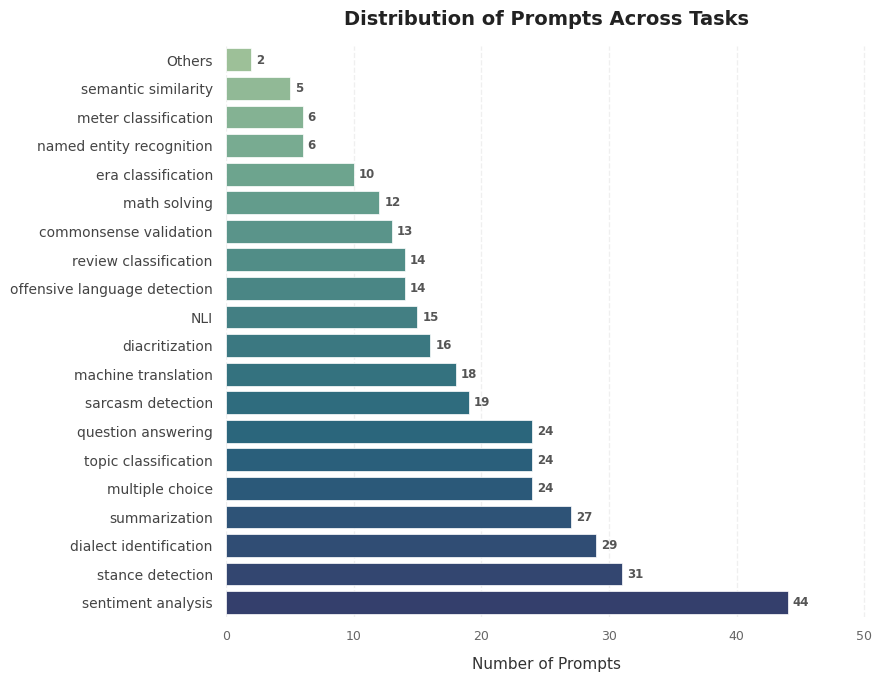

In [6]:
task_counts = approved['task_grouped'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
bars = sns.barplot(
    x=task_counts.values, y=task_counts.index,
    hue=task_counts.index, palette='crest', legend=False,
    ax=ax, edgecolor='white', linewidth=0.5
)
for i, v in enumerate(task_counts.values):
    ax.text(v + 0.4, i, str(v), va='center', fontsize=8.5,
            fontweight='semibold', color='#555555')
ax.set_xlabel('Number of Prompts', fontsize=11, color='#333333', labelpad=10)
ax.set_ylabel('')
ax.set_title('Distribution of Prompts Across Tasks',
             fontsize=14, fontweight='bold', color='#222222', pad=15)
ax.tick_params(axis='y', labelsize=10, colors='#444444')
ax.tick_params(axis='x', labelsize=9, colors='#666666')
ax.set_xlim(0, task_counts.max() * 1.14)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig('Notebooks/explore_prompts_dataset/prompts_per_task.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Prompts per Prompter

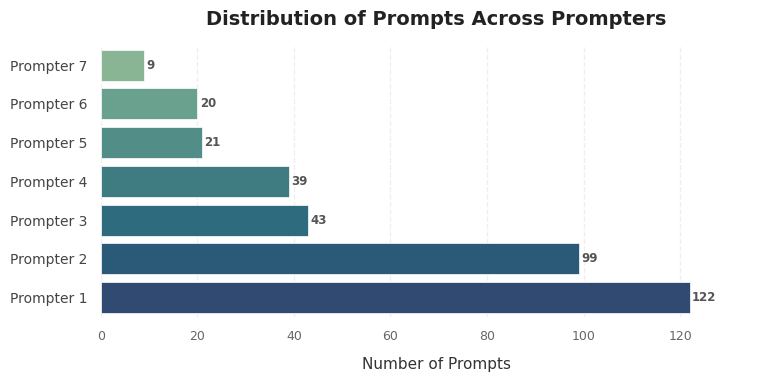

In [7]:
prompter_counts_labeled = approved['prompter_label'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bars = sns.barplot(
    x=prompter_counts_labeled.values, y=prompter_counts_labeled.index,
    hue=prompter_counts_labeled.index, palette='crest', legend=False,
    ax=ax, edgecolor='white', linewidth=0.5
)
for i, v in enumerate(prompter_counts_labeled.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=8.5,
            fontweight='semibold', color='#555555')
ax.set_xlabel('Number of Prompts', fontsize=11, color='#333333', labelpad=10)
ax.set_ylabel('')
ax.set_title('Distribution of Prompts Across Prompters',
             fontsize=14, fontweight='bold', color='#222222', pad=15)
ax.tick_params(axis='y', labelsize=10, colors='#444444')
ax.tick_params(axis='x', labelsize=9, colors='#666666')
ax.set_xlim(0, prompter_counts_labeled.max() * 1.14)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig('Notebooks/explore_prompts_dataset/prompts_per_prompter.pdf', bbox_inches='tight', dpi=300)
plt.show()